In [12]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# Para mostrar los gráficos dentro del notebook
%matplotlib inline 


In [ ]:
ex = pd.read_csv('C:/Users/HP/Desktop/Universidad/Tec CsDatos/Analisis y Visualizacion de Datos/ARCHIVOS/API 3/exportaciones.csv' , encoding = 'latin-1')
ex.head() # Veremos las primeras 5 filas 

,rubro,provincia,anio,value
0,Total,Total País,2005,40386.762
1,Total,Buenos Aires,2005,15626.865
2,Total,Capital Federal,2005,271.295
3,Total,Córdoba,2005,4452.178
4,Total,Entre Ríos,2005,815.341


In [ ]:
#Generamos un nuevo DataFrame 
copy = ex.copy()
copy.dtypes
# Conversión segura con to_numeric
copy['value'] = pd.to_numeric(copy['value'], errors='coerce') # Convertimos a numérico, los errores se convierten en NaN
copy.dtypes
copy

,rubro,provincia,anio,value
0,Total,Total País,2005,40386.762
1,Total,Buenos Aires,2005,15626.865
2,Total,Capital Federal,2005,271.295
3,Total,Córdoba,2005,4452.178
4,Total,Entre Ríos,2005,815.341
...,...,...,...,...
1995,Combustibles y energía,San Luis,2020,0.000
1996,Combustibles y energía,Chaco,2020,0.000
1997,Combustibles y energía,Corrientes,2020,373.938
1998,Combustibles y energía,Formosa,2020,5.169


In [ ]:
# Filtramos los datos que vamos a graficar 
productos = copy[copy['rubro'] == 'Productos primarios'] 
productos.head()
total = copy[copy["rubro"] == 'Total']
total.head()

,rubro,provincia,anio,value
0,Total,Total País,2005,40386.762
1,Total,Buenos Aires,2005,15626.865
2,Total,Capital Federal,2005,271.295
3,Total,Córdoba,2005,4452.178
4,Total,Entre Ríos,2005,815.341


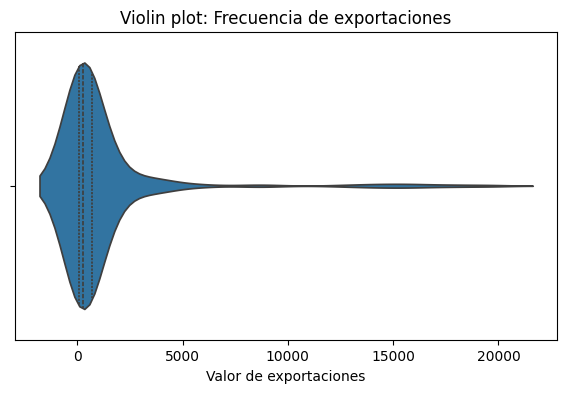

In [ ]:
plt.figure(figsize=(7,4))
sns.violinplot(x=productos["value"], inner="quartile")  # Violin Plot - Horizontal 
plt.title("Violin plot: Frecuencia de exportaciones")
plt.xlabel("Valor de exportaciones")
plt.show()

In [35]:
    # Grafico en Barra para comparar. (B)
total_pr = total[total['provincia'] == 'Total País'] # Filtramos para la comparacion

productos['subtotal_anio'] = productos.groupby('anio')['value'].transform('sum') # Genero una nueva variable con subtotales
productos_anio = productos[productos['provincia'] == 'Total País'] # Filtramos para la comparacion  
productos_anio.head()

comparacion = pd.merge(productos_anio , total_pr , on = 'anio' , how = 'inner') # Hacemos un merge para comparar los datos
comparacion.head()
comparacion = comparacion.drop( columns = ['value_x' , 'rubro_y' , 'provincia_y']) # Eliminamos columnas que no vamos a usar
comparacion = comparacion.rename( columns = {'value_y' : 'valor_total'}) # Renombramos la columna para que sea mas clara
comparacion.head()


,rubro_x,provincia_x,anio,subtotal_anio,valor_total
0,Productos primarios,Total País,2005,16155.028,40386.762
1,Productos primarios,Total País,2006,17148.580,46546.203
2,Productos primarios,Total País,2007,24848.095,55980.309
3,Productos primarios,Total País,2008,32259.090,70018.839
4,Productos primarios,Total País,2009,18422.946,55672.097


<Axes: xlabel='anio'>

<Figure size 800x650 with 0 Axes>

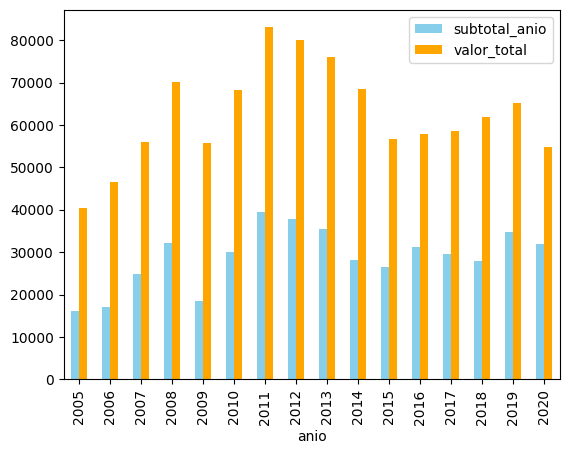

In [47]:
plt.figure(figsize = (8 , 6.5))

# GRAFICO DE BARRAS # 
comparacion.plot(x = 'anio' , y = ['subtotal_anio' , 'valor_total'] , kind = 'bar' , color = ['skyblue' , 'orange'])


Text(0, 0.5, 'Valor_exportaciones')

<Figure size 600x450 with 0 Axes>

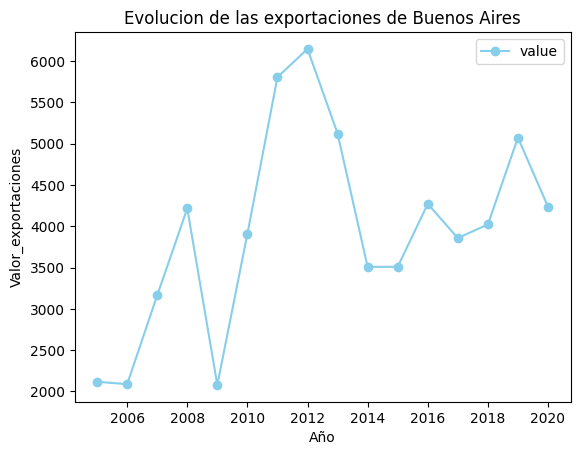

In [ ]:
 #GRAFICO LINEAL# (2C)
productos = productos[productos['provincia'] == 'Buenos Aires'] # Filtramos el dato para graficar solo BsAs
productos.head()
plt.figure( figsize = ( 6 , 4.5))
productos.plot( x = 'anio' , y = 'value' , kind = 'line' , color = 'skyblue' , marker = 'o'
               ) # Grafico lineal con marcadores
plt.title('Evolucion de las exportaciones de Buenos Aires')
plt.xlabel('Año')
plt.ylabel('Valor_exportaciones')
